In [1]:
from blastdesign import (
    build_gole_gohar_ucs_sensitivity_table,
    build_model_ucs_response_summary,
    build_ucs_ensemble_summary,
)

sensitivity_table = build_gole_gohar_ucs_sensitivity_table()

ensemble_summary = build_ucs_ensemble_summary(
    sensitivity_table
)

model_response_summary = build_model_ucs_response_summary(
    sensitivity_table
)

display(sensitivity_table)
display(ensemble_summary)
display(model_response_summary)

,ucs_mpa,model_id,model_name,burden_m
0,40.0,CONV_ASH,Ash,6.275000
1,40.0,CONV_BHANDARI,Bhandari,6.874000
2,40.0,CONV_JIMENO,Lopez Jimeno,7.028000
3,40.0,CONV_KONYA_1972,Konya 1972,5.527324
4,40.0,CONV_KONYA_1983,Konya 1983,5.689716
...,...,...,...,...
72,220.0,CONV_JIMENO,Lopez Jimeno,5.271000
73,220.0,CONV_KONYA_1972,Konya 1972,5.527324
74,220.0,CONV_KONYA_1983,Konya 1983,5.689716
75,220.0,CONV_RUSTAN,Rustan,6.983189


,ucs_mpa,model_count,mean_burden_m,median_burden_m,minimum_burden_m,maximum_burden_m,range_m
0,40.000,7,6.474013,6.874000,5.527324,7.028000,1.500676
1,54.999,7,6.474013,6.874000,5.527324,7.028000,1.500676
2,55.000,7,6.316657,6.275000,5.527324,7.028000,1.500676
3,69.999,7,6.316657,6.275000,5.527324,7.028000,1.500676
4,70.000,7,6.137371,5.839370,5.527324,6.983189,1.455865
5,85.000,7,6.137371,5.839370,5.527324,6.983189,1.455865
6,110.000,7,6.137371,5.839370,5.527324,6.983189,1.455865
7,110.001,7,6.030187,5.773000,5.089080,6.983189,1.894109
8,180.000,7,6.030187,5.773000,5.089080,6.983189,1.894109
9,180.001,7,5.958473,5.689716,5.089080,6.983189,1.894109


,model_id,model_name,distinct_burden_count,responds_to_ucs,reference_ucs_mpa,reference_burden_m,minimum_burden_m,maximum_burden_m,burden_range_m
0,CONV_ASH,Ash,1,False,85.0,6.275000,6.275000,6.275000,0.00000
1,CONV_BHANDARI,Bhandari,1,False,85.0,6.874000,6.874000,6.874000,0.00000
2,CONV_JIMENO,Lopez Jimeno,3,True,85.0,5.773000,5.271000,7.028000,1.75700
3,CONV_KONYA_1972,Konya 1972,1,False,85.0,5.527324,5.527324,5.527324,0.00000
4,CONV_KONYA_1983,Konya 1983,1,False,85.0,5.689716,5.689716,5.689716,0.00000
5,CONV_RUSTAN,Rustan,1,False,85.0,6.983189,6.983189,6.983189,0.00000
6,CONV_TATIYA,Tatiya–Al-Ajmi,3,True,85.0,5.839370,5.089080,6.940860,1.85178


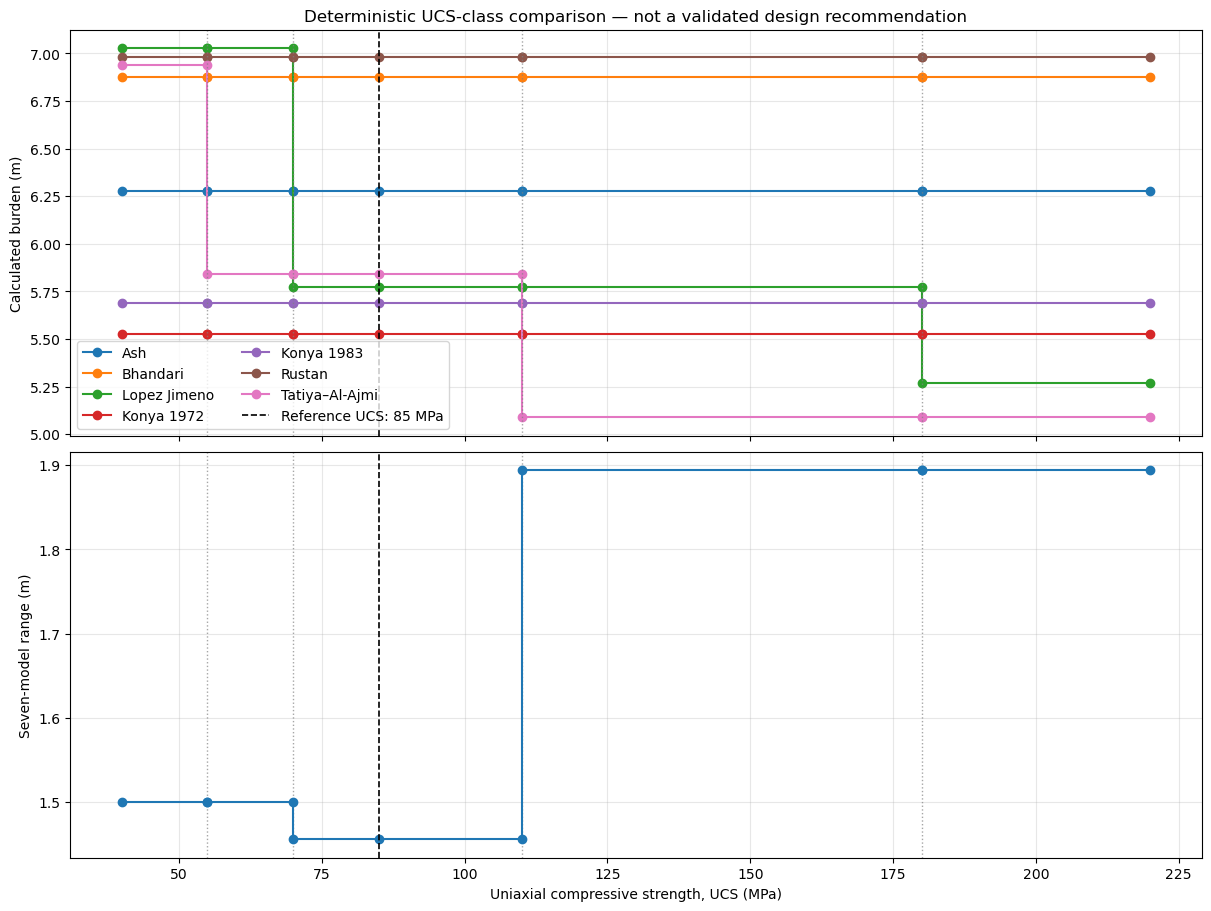

Figure saved to: C:\Users\A.Mehregan\Projects\BlastDesign-AI\outputs\figures\ucs_sensitivity_comparison.png


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt


project_root = Path.cwd()

if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

figure_directory = project_root / "outputs" / "figures"
figure_directory.mkdir(parents=True, exist_ok=True)

figure, axes = plt.subplots(
    2,
    1,
    figsize=(12, 9),
    sharex=True,
    constrained_layout=True,
)

for model_id, group in sensitivity_table.groupby(
    "model_id",
    sort=False,
):
    ordered = group.sort_values("ucs_mpa")

    axes[0].plot(
        ordered["ucs_mpa"],
        ordered["burden_m"],
        marker="o",
        drawstyle="steps-post",
        label=ordered["model_name"].iloc[0],
    )

for threshold in (55.0, 70.0, 110.0, 180.0):
    for axis in axes:
        axis.axvline(
            threshold,
            color="gray",
            linestyle=":",
            linewidth=1,
            alpha=0.7,
        )

axes[0].axvline(
    85.0,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Reference UCS: 85 MPa",
)

axes[0].set_title(
    "Deterministic UCS-class comparison — "
    "not a validated design recommendation"
)
axes[0].set_ylabel("Calculated burden (m)")
axes[0].grid(True, alpha=0.3)
axes[0].legend(ncol=2)

axes[1].plot(
    ensemble_summary["ucs_mpa"],
    ensemble_summary["range_m"],
    marker="o",
    drawstyle="steps-post",
)

axes[1].axvline(
    85.0,
    color="black",
    linestyle="--",
    linewidth=1.2,
)

axes[1].set_xlabel("Uniaxial compressive strength, UCS (MPa)")
axes[1].set_ylabel("Seven-model range (m)")
axes[1].grid(True, alpha=0.3)

figure_path = (
    figure_directory
    / "ucs_sensitivity_comparison.png"
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {figure_path}")

## Interpretation

This analysis varies uniaxial compressive strength (UCS) while holding the other Gole Gohar reference inputs constant.

Five of the seven reconstructed burden equations remain unchanged because UCS is not an explicit input to those equations. Only the López Jimeno and Tatiya–Al-Ajmi implementations respond to UCS.

### Documented class transitions

- **Tatiya–Al-Ajmi:** transitions occur at 55 MPa and immediately above 110 MPa.
- **López Jimeno:** transitions occur at 70 MPa and immediately above 180 MPa.
- The closely spaced values around these boundaries deliberately test the implemented piecewise conditions.

At the reference UCS of **85 MPa**, the seven-model burden range is approximately **1.456 m**, reproducing the established reference comparison.

Across the sampled UCS classes:

- The seven-model range is approximately **1.501 m** below the López Jimeno 70 MPa transition.
- It is approximately **1.456 m** for the reference strength class.
- It increases to approximately **1.894 m** immediately above the Tatiya–Al-Ajmi 110 MPa transition.

The abrupt changes are consequences of discrete empirical classification rules. They must not be interpreted as physical discontinuities in rock behavior, calibrated uncertainty bounds, or evidence of predictive accuracy.

```text
Decision gate: RESEARCH_COMPARATOR_ONLY
Recommended burden: None

In [3]:
data_directory = project_root / "data" / "processed"
data_directory.mkdir(parents=True, exist_ok=True)

model_outputs_path = (
    data_directory
    / "ucs_sensitivity_model_outputs.csv"
)

ensemble_summary_path = (
    data_directory
    / "ucs_sensitivity_ensemble_summary.csv"
)

model_response_path = (
    data_directory
    / "ucs_sensitivity_model_response_summary.csv"
)

sensitivity_table.to_csv(
    model_outputs_path,
    index=False,
)

ensemble_summary.to_csv(
    ensemble_summary_path,
    index=False,
)

model_response_summary.to_csv(
    model_response_path,
    index=False,
)

print(
    f"{model_outputs_path.name}: "
    f"{len(sensitivity_table)} rows"
)

print(
    f"{ensemble_summary_path.name}: "
    f"{len(ensemble_summary)} rows"
)

print(
    f"{model_response_path.name}: "
    f"{len(model_response_summary)} rows"
)

ucs_sensitivity_model_outputs.csv: 77 rows
ucs_sensitivity_ensemble_summary.csv: 11 rows
ucs_sensitivity_model_response_summary.csv: 7 rows
